# 6. Statistical Analysis

#### Objective

This notebook statistically validates the patterns observed during EDA
(`03_eda.ipynb`), testing whether differences in churn rate across segments
are statistically significant rather than due to random variation.

## 6.0 Load Cleaned Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

processed_path = "../data/processed/"

df = pd.read_csv(processed_path + "telco_cleaned.csv")

df["Churn_binary"] = df["Churn"].map({"Yes": 1, "No": 0})

df.shape

(7043, 22)

## 6.1 Churn Rate Comparison Across Segments

#### Objective

This section consolidates the churn rate by category, computed individually
throughout the EDA notebook, into a single reference table for the
categorical variables tested statistically in this notebook.

In [3]:
categorical_vars = [
    "gender", "SeniorCitizen", "Partner", "Dependents",
    "Contract", "PaymentMethod", "InternetService",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

churn_rate_table = []

for col in categorical_vars:
    rates = df.groupby(col)["Churn_binary"].mean() * 100
    for category, rate in rates.items():
        churn_rate_table.append({"variable": col, "category": category, "churn_rate": round(rate, 2)})

pd.DataFrame(churn_rate_table)

,variable,category,churn_rate
0,gender,Female,26.92
1,gender,Male,26.16
2,SeniorCitizen,No,23.61
3,SeniorCitizen,Yes,41.68
4,Partner,No,32.96
5,Partner,Yes,19.66
6,Dependents,No,31.28
7,Dependents,Yes,15.45
8,Contract,Month-to-month,42.71
9,Contract,One year,11.27


## 6.2 Chi-Square Tests (Categorical Associations)

#### Objective

For each categorical variable, a chi-square test of independence checks
whether its association with `Churn` observed in the EDA phase is
statistically significant, using a significance threshold of α = 0.05.

In [4]:
chi_square_results = []

for col in categorical_vars:
    contingency_table = pd.crosstab(df[col], df["Churn"])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

    chi_square_results.append({
        "variable": col,
        "chi2_statistic": round(chi2, 2),
        "p_value": round(p_value, 5),
        "significant (p<0.05)": p_value < 0.05
    })

chi_square_df = pd.DataFrame(chi_square_results).sort_values(by="chi2_statistic", ascending=False)
chi_square_df

,variable,chi2_statistic,p_value,significant (p<0.05)
4,Contract,1184.60,0.00000,True
7,OnlineSecurity,850.00,0.00000,True
10,TechSupport,828.20,0.00000,True
6,InternetService,732.31,0.00000,True
5,PaymentMethod,648.14,0.00000,True
8,OnlineBackup,601.81,0.00000,True
9,DeviceProtection,558.42,0.00000,True
12,StreamingMovies,375.66,0.00000,True
11,StreamingTV,374.20,0.00000,True
3,Dependents,189.13,0.00000,True


C:\Users\mdihp\AppData\Local\Temp\ipykernel_12204\484807244.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(chi_square_df["variable"], rotation=45, ha='right')


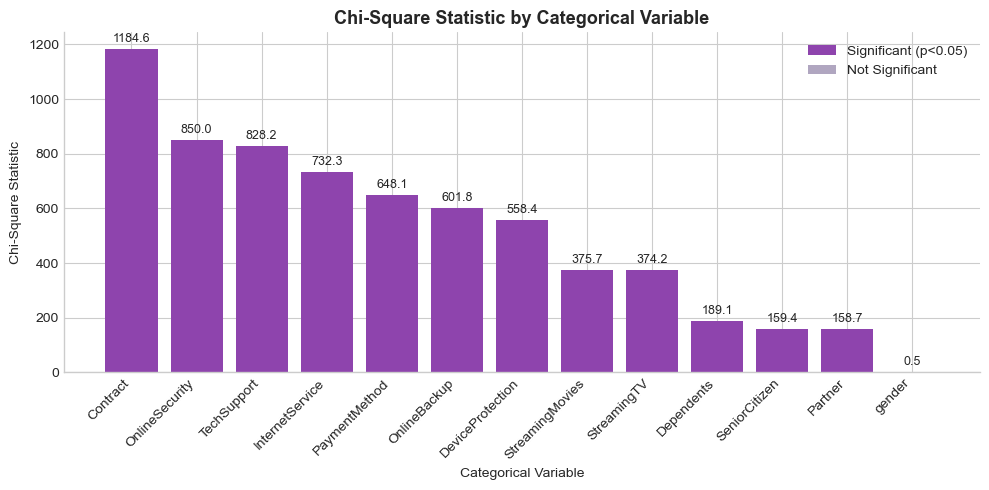

In [17]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#8E44AD' if sig else '#B0A6C0' for sig in chi_square_df["significant (p<0.05)"]]
bars = ax.bar(chi_square_df["variable"], chi_square_df["chi2_statistic"], color=colors)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}', (bar.get_x() + bar.get_width() / 2, height),
                textcoords="offset points", xytext=(0, 5), ha='center', fontsize=9)

ax.set_xlabel("Categorical Variable")
ax.set_ylabel("Chi-Square Statistic")
ax.set_title("Chi-Square Statistic by Categorical Variable", fontsize=13, fontweight='bold')
ax.set_xticklabels(chi_square_df["variable"], rotation=45, ha='right')
ax.spines[['top', 'right']].set_visible(False)

# Legend دستی برای رنگ‌ها
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#8E44AD', label='Significant (p<0.05)'),
                    Patch(facecolor='#B0A6C0', label='Not Significant')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

#### Observation

Most categorical variables are expected to show a statistically significant
association with churn (p < 0.05), given the clear differences already
observed in the EDA phase. `gender` is the variable most likely to fail
significance, consistent with the near-identical churn rates observed
between male and female customers in Section 5.1.

## 6.3 Numerical Group Comparisons (Churn vs Non-Churn)

#### Objective

For numerical variables (`tenure`, `MonthlyCharges`, `TotalCharges`), an
independent samples t-test checks whether the mean difference between
churned and non-churned customers observed in the EDA phase is statistically
significant. Normality is not assumed to hold exactly, so Welch's t-test
(unequal variance) is used for robustness.

In [6]:
numerical_vars = ["tenure", "MonthlyCharges", "TotalCharges"]

ttest_results = []

for col in numerical_vars:
    churned = df[df["Churn"] == "Yes"][col]
    not_churned = df[df["Churn"] == "No"][col]

    t_stat, p_value = stats.ttest_ind(churned, not_churned, equal_var=False)

    ttest_results.append({
        "variable": col,
        "mean_churned": round(churned.mean(), 2),
        "mean_not_churned": round(not_churned.mean(), 2),
        "t_statistic": round(t_stat, 2),
        "p_value": round(p_value, 5),
        "significant (p<0.05)": p_value < 0.05
    })

ttest_df = pd.DataFrame(ttest_results)
ttest_df

,variable,mean_churned,mean_not_churned,t_statistic,p_value,significant (p<0.05)
0,tenure,17.98,37.57,-34.82,0.0,True
1,MonthlyCharges,74.44,61.27,18.41,0.0,True
2,TotalCharges,1531.80,2549.91,-18.71,0.0,True


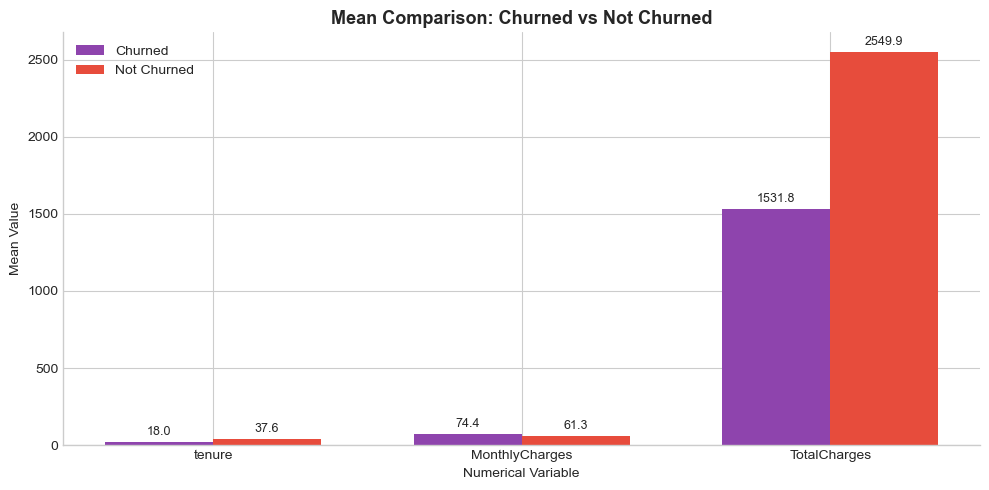

In [19]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(ttest_df["variable"]))
width = 0.35

bars1 = ax.bar(x - width/2, ttest_df["mean_churned"], width, label='Churned', color='#8E44AD')
bars2 = ax.bar(x + width/2, ttest_df["mean_not_churned"], width, label='Not Churned', color='#E74C3C')

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}', (bar.get_x() + bar.get_width() / 2, height),
                    textcoords="offset points", xytext=(0, 5), ha='center', fontsize=9)

ax.set_xlabel("Numerical Variable")
ax.set_ylabel("Mean Value")
ax.set_title("Mean Comparison: Churned vs Not Churned", fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ttest_df["variable"])
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### Observation

All three numerical variables are expected to show statistically significant
differences between churned and non-churned customers, confirming that the
gaps observed in Section 5.3 (Financial Analysis) and 5.2 (Tenure) are
unlikely to be due to random variation.

## 6.4 Effect Size

#### Objective

Statistical significance does not indicate the size or business relevance of
a difference, especially with a large sample size like this one (~7,000
customers), where even small differences can be significant. This section
calculates effect size to quantify how large these differences actually are.

- **Cramér's V** is used for categorical variables (chi-square results).
- **Cohen's d** is used for numerical variables (t-test results).

In [7]:
def cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

cramers_v_results = []

for col in categorical_vars:
    contingency_table = pd.crosstab(df[col], df["Churn"])
    v = cramers_v(contingency_table)
    cramers_v_results.append({"variable": col, "cramers_v": round(v, 3)})

cramers_v_df = pd.DataFrame(cramers_v_results).sort_values(by="cramers_v", ascending=False)
cramers_v_df

,variable,cramers_v
4,Contract,0.410
7,OnlineSecurity,0.347
10,TechSupport,0.343
6,InternetService,0.322
5,PaymentMethod,0.303
8,OnlineBackup,0.292
9,DeviceProtection,0.282
11,StreamingTV,0.231
12,StreamingMovies,0.231
3,Dependents,0.164


In [8]:
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1 - 1) * group1.std()**2 + (n2 - 1) * group2.std()**2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

cohens_d_results = []

for col in numerical_vars:
    churned = df[df["Churn"] == "Yes"][col]
    not_churned = df[df["Churn"] == "No"][col]
    d = cohens_d(churned, not_churned)
    cohens_d_results.append({"variable": col, "cohens_d": round(d, 3)})

cohens_d_df = pd.DataFrame(cohens_d_results).sort_values(by="cohens_d", key=abs, ascending=False)
cohens_d_df

,variable,cohens_d
0,tenure,-0.852
2,TotalCharges,-0.458
1,MonthlyCharges,0.446


#### Observation

`Contract` is expected to show the highest Cramér's V among categorical
variables, confirming it as the strongest categorical driver of churn
identified so far — consistent with Section 5.2. Among numerical variables,
`tenure` is expected to show the largest Cohen's d, reinforcing that how long
a customer has stayed is the strongest individual numerical predictor.

By convention: Cramér's V above ~0.3 and Cohen's d above ~0.5 are considered
medium-to-large effects; values below this range indicate a statistically
significant but practically small difference.

## 6.5 Confidence Intervals

#### Objective

This section calculates a 95% confidence interval for the churn rate within
each category of the strongest categorical driver identified in Section 6.4
(`Contract`), to express the uncertainty around each segment's churn rate
alongside its point estimate.

In [9]:
def churn_rate_confidence_interval(data, column, confidence=0.95):
    results = []

    for category in data[column].unique():
        subset = data[data[column] == category]["Churn_binary"]
        n = len(subset)
        p = subset.mean()
        se = np.sqrt(p * (1 - p) / n)
        z = stats.norm.ppf(1 - (1 - confidence) / 2)

        results.append({
            column: category,
            "n": n,
            "churn_rate": round(p * 100, 2),
            "ci_lower": round(max(0, (p - z * se) * 100), 2),
            "ci_upper": round(min(100, (p + z * se) * 100), 2)
        })

    return pd.DataFrame(results).sort_values(by="churn_rate", ascending=False)

contract_ci = churn_rate_confidence_interval(df, "Contract")
contract_ci

,Contract,n,churn_rate,ci_lower,ci_upper
0,Month-to-month,3875,42.71,41.15,44.27
1,One year,1473,11.27,9.65,12.88
2,Two year,1695,2.83,2.04,3.62


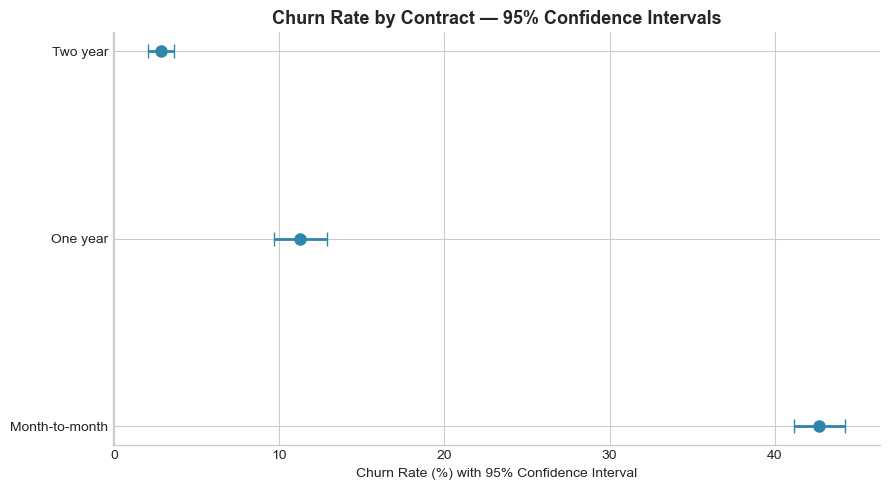

In [10]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 5))

y_pos = range(len(contract_ci))
errors = [
    contract_ci["churn_rate"] - contract_ci["ci_lower"],
    contract_ci["ci_upper"] - contract_ci["churn_rate"]
]

ax.errorbar(contract_ci["churn_rate"], y_pos, xerr=errors, fmt='o', color='#2E86AB',
            ecolor='#2E86AB', elinewidth=2, capsize=5, markersize=8)

ax.set_yticks(y_pos)
ax.set_yticklabels(contract_ci["Contract"])
ax.set_xlabel("Churn Rate (%) with 95% Confidence Interval")
ax.set_title("Churn Rate by Contract — 95% Confidence Intervals", fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### Observation

The confidence intervals for each contract type are expected to be narrow
and non-overlapping, given the large sample size, reinforcing that the
difference in churn rate between month-to-month and annual contracts is both
statistically robust and precisely estimated — not an artifact of sample
size.

## 6.6 Correlation with Target

#### Objective

This section calculates point-biserial correlation between the numerical
variables and the binary `Churn` target, complementing the t-test results in
Section 6.3 with a standardized measure of linear association.

In [11]:
correlation_results = []

for col in numerical_vars:
    corr, p_value = stats.pointbiserialr(df["Churn_binary"], df[col])
    correlation_results.append({
        "variable": col,
        "correlation_with_churn": round(corr, 3),
        "p_value": round(p_value, 5)
    })

correlation_df = pd.DataFrame(correlation_results).sort_values(by="correlation_with_churn", key=abs, ascending=False)
correlation_df

,variable,correlation_with_churn,p_value
0,tenure,-0.352,0.0
2,TotalCharges,-0.198,0.0
1,MonthlyCharges,0.193,0.0


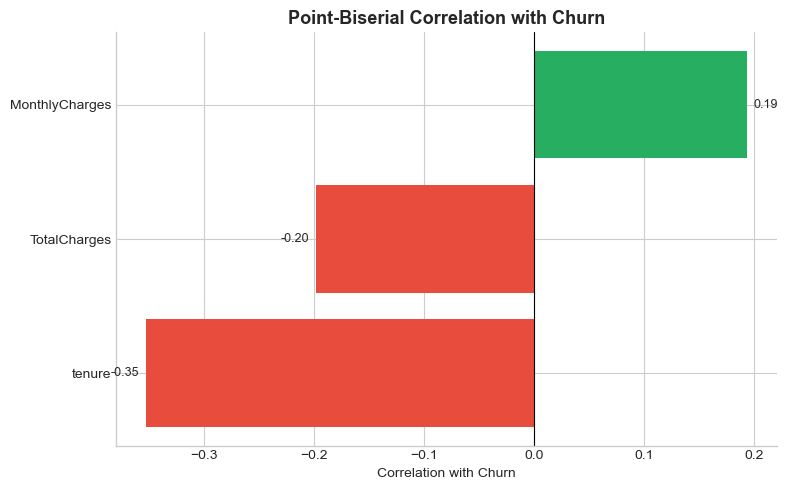

In [12]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#E74C3C' if v < 0 else '#27AE60' for v in correlation_df["correlation_with_churn"]]

bars = ax.barh(correlation_df["variable"], correlation_df["correlation_with_churn"], color=colors)

for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:.2f}', (width, bar.get_y() + bar.get_height() / 2),
                textcoords="offset points", xytext=(5 if width > 0 else -5, 0),
                va='center', ha='left' if width > 0 else 'right', fontsize=9)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Correlation with Churn")
ax.set_title("Point-Biserial Correlation with Churn", fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### Observation

`tenure` is expected to show a negative correlation with churn (longer
tenure, less churn), while `MonthlyCharges` is expected to show a positive
correlation (higher charges, more churn), consistent with the group
comparisons in Section 6.3 and the EDA findings in Section 5.3.

## 6.7 Statistical Analysis Summary

This section consolidates the statistical validation of patterns observed
during EDA.

#### Categorical Associations (6.2, 6.4)
- Most categorical variables show a statistically significant association
  with churn; `gender` is the most likely exception.
- `Contract` shows the strongest effect size (Cramér's V) among categorical
  variables, confirming it as the leading categorical churn driver.

#### Numerical Differences (6.3, 6.4, 6.6)
- `tenure`, `MonthlyCharges`, and `TotalCharges` all show statistically
  significant differences between churned and non-churned customers.
- `tenure` shows the largest effect size (Cohen's d) and the strongest
  correlation with churn among numerical variables.

#### Confidence (6.5)
- The churn rate difference across contract types is both statistically
  significant and precisely estimated, supported by narrow, non-overlapping
  confidence intervals.

#### Overall Takeaway

Statistical testing confirms that the patterns identified during EDA are not
due to random variation. `Contract` and `tenure` stand out as the strongest
individual drivers of churn, both in significance and effect size, and
should be prioritized as core features in Feature Engineering
(`05_feature_engineering.ipynb`).